# Apply Findings for UMSI Expo 2026

This notebook applies the findings and explores the impact and implications.

## 0. Initializations

In [49]:
## 0. Initializations
# -- imports --
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns

from signals_in_the_noise.preprocessing.gse161529 import GSE161529

In [2]:
# -- datasets --
gse = GSE161529()

## 1. Determine what is still noise

In [11]:
from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes

all_noise = []
for filename, adata in gse.objects.items():
    adata_noise = adata[adata.obs["is_noise"] == 1].copy()
    classify_noise_subtypes(adata_noise)
    adata_noise.obs["still_noise"] = (
        # observation is NOT a potential biological signal
        (adata_noise.obs[["pbs-1", "pbs-2", "pbs-3"]] == 0).all(axis=1)
        & (adata_noise.obs["is_noise"] == 1)
    )
    adata_noise.obs["cancer_type"] = adata_noise.uns["cancer_type"]
    adata_noise.raw = adata_noise.copy()
    all_noise.append(adata_noise)


In [12]:
all_noise = ad.concat(all_noise, join="inner")

C:\Users\silly\miniconda3\envs\signals-in-the-noise\Lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\silly\miniconda3\envs\signals-in-the-noise\Lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [13]:
all_noise.obs_names_make_unique()

In [6]:
import json, time, numpy as np
from pathlib import Path

_X = all_noise.X if not hasattr(all_noise.X, "toarray") else all_noise.X.toarray()
_log = {
    "sessionId": "326cc9",
    "timestamp": int(time.time() * 1000),
    "location": "09-umsi-expo-findings.ipynb:pre-hvg",
    "message": "X state before HVG",
    "hypothesisId": "H-A,H-B,H-C,H-D",
    "data": {
        "X_min": float(np.nanmin(_X)),
        "X_max": float(np.nanmax(_X)),
        "X_has_inf": bool(np.any(np.isinf(_X))),
        "X_has_nan": bool(np.any(np.isnan(_X))),
        "X_has_negative": bool(np.any(_X < 0)),
        "X_dtype": str(_X.dtype),
        "has_raw": all_noise.raw is not None,
        "obsm_keys": list(all_noise.obsm.keys()),
        "n_obs": all_noise.n_obs,
        "n_vars": all_noise.n_vars,
    }
}
with open("debug-326cc9.log", "a") as _f:
    _f.write(json.dumps(_log) + "\n")
print(_log["data"])

{'X_min': 0.0, 'X_max': 10061.0, 'X_has_inf': False, 'X_has_nan': False, 'X_has_negative': False, 'X_dtype': 'float32', 'has_raw': True, 'obsm_keys': [], 'n_obs': 87044, 'n_vars': 33538}


In [36]:
print(all_noise_her.n_obs)

0


In [14]:
sc.pp.normalize_total(all_noise)
sc.pp.log1p(all_noise)

In [15]:
sc.pp.highly_variable_genes(all_noise)
all_noise_hvg = all_noise[:, all_noise.var["highly_variable"]].copy()

In [16]:
gse.find_clusters(all_noise_hvg)

C:\Users\silly\GitHub\signals-in-the-noise\src\signals_in_the_noise\preprocessing\gse161529.py:498: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, **default_cluster_parameters)


In [17]:
gse.calculate_tsne(all_noise_hvg, tsne_kwargs={"n_jobs": 3})

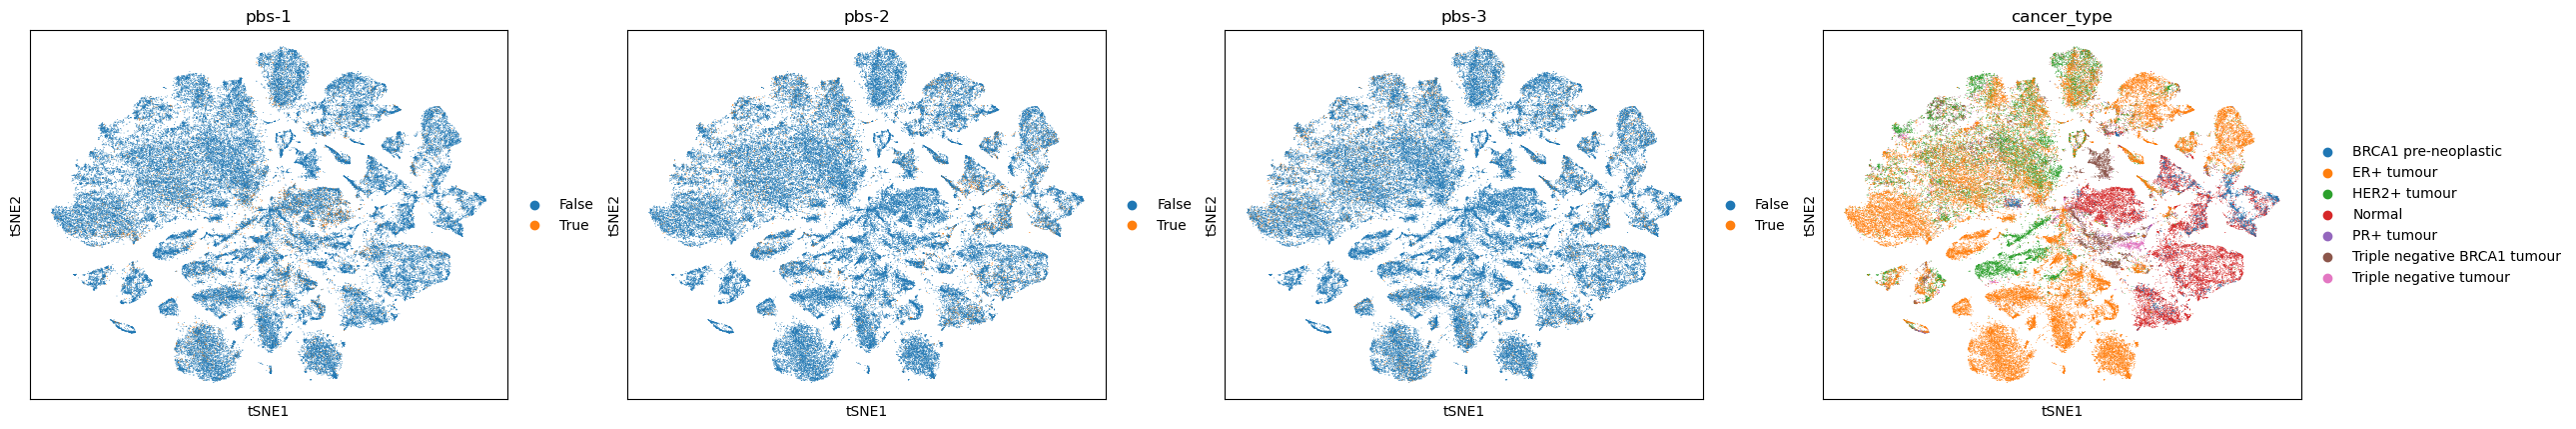

In [18]:
gse.visualize_tsne(all_noise_hvg, color=["pbs-1", "pbs-2", "pbs-3", "cancer_type"])

In [25]:
all_noise_hvg.obs['cancer_type'].unique()

['Normal', 'BRCA1 pre-neoplastic', 'Triple negative tumour', 'Triple negative BRCA1 tumour', 'HER2+ tumour', 'PR+ tumour', 'ER+ tumour']
Categories (7, object): ['BRCA1 pre-neoplastic', 'ER+ tumour', 'HER2+ tumour', 'Normal', 'PR+ tumour', 'Triple negative BRCA1 tumour', 'Triple negative tumour']

In [29]:
all_noise_er = all_noise[all_noise.obs['cancer_type'] == 'ER+ tumour']

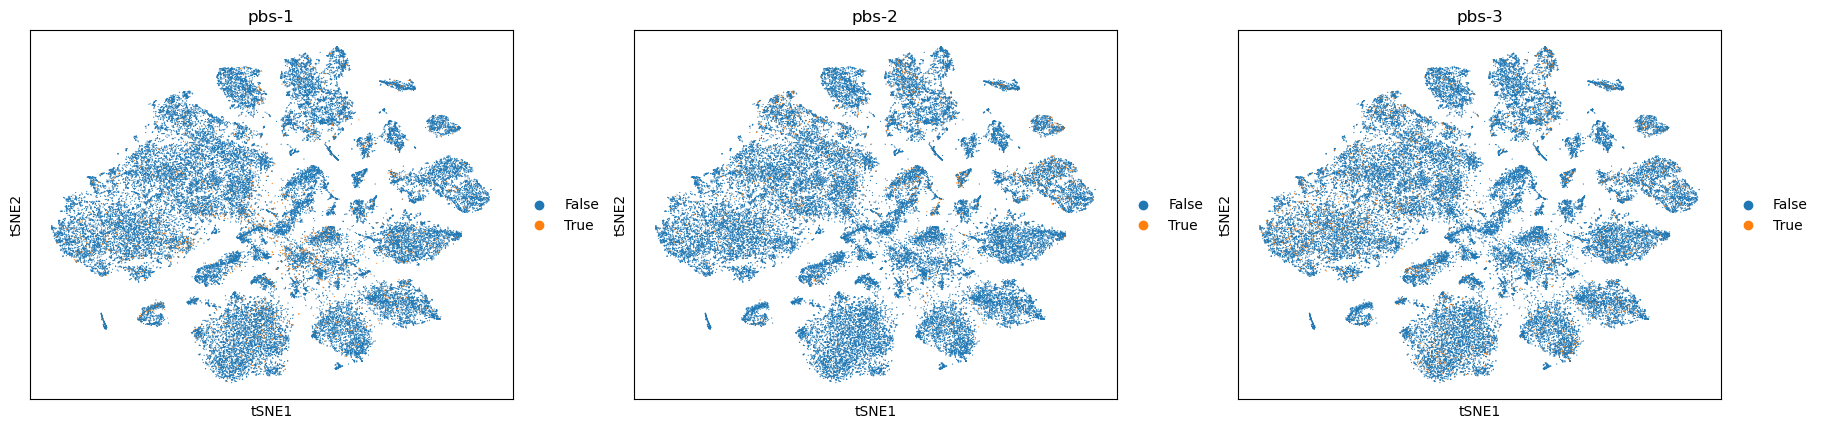

In [38]:
sc.pp.highly_variable_genes(all_noise_er)
all_noise_er_hvg = all_noise_er[:, all_noise_er.var["highly_variable"]].copy()
gse.find_clusters(all_noise_er_hvg, cluster_kwargs={"resolution": 0.05})
gse.calculate_tsne(all_noise_er_hvg, tsne_kwargs={"n_jobs": 3})
gse.visualize_tsne(all_noise_er_hvg, color=["pbs-1", "pbs-2", "pbs-3"])

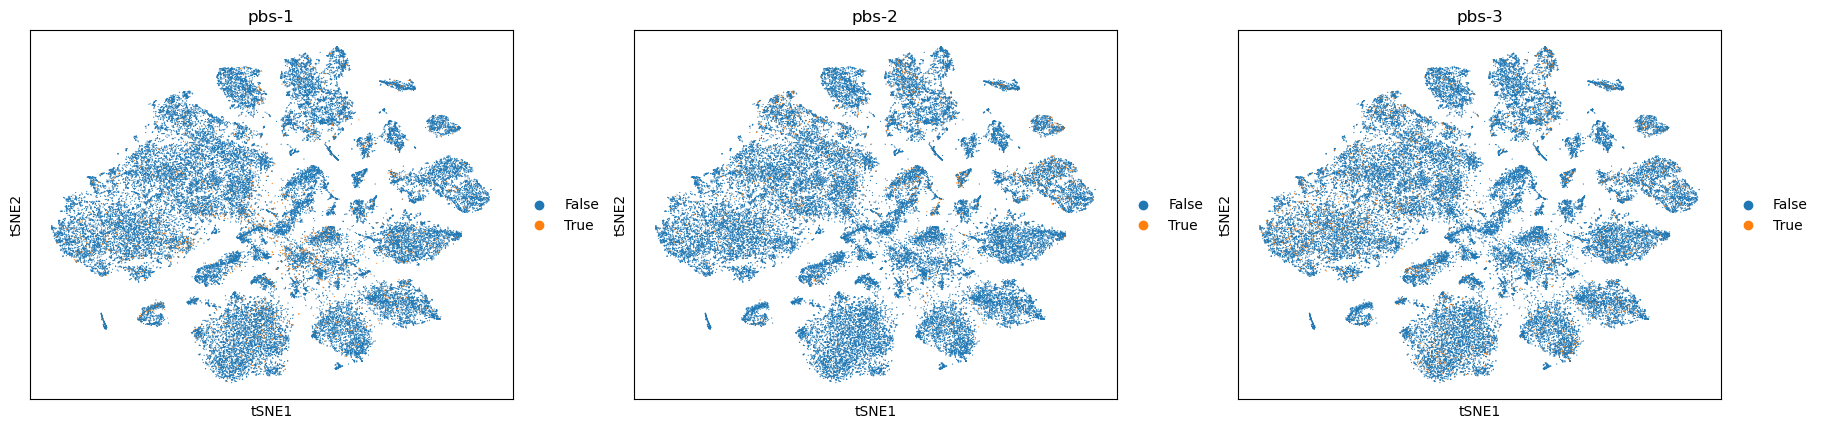

In [40]:
sc.pp.highly_variable_genes(all_noise_er)
all_noise_er_hvg = all_noise_er[:, all_noise_er.var["highly_variable"]].copy()
gse.find_clusters(all_noise_er_hvg, cluster_kwargs={"resolution": 0.3})
gse.calculate_tsne(all_noise_er_hvg, tsne_kwargs={"n_jobs": 3})
gse.visualize_tsne(all_noise_er_hvg, color=["pbs-1", "pbs-2", "pbs-3"])

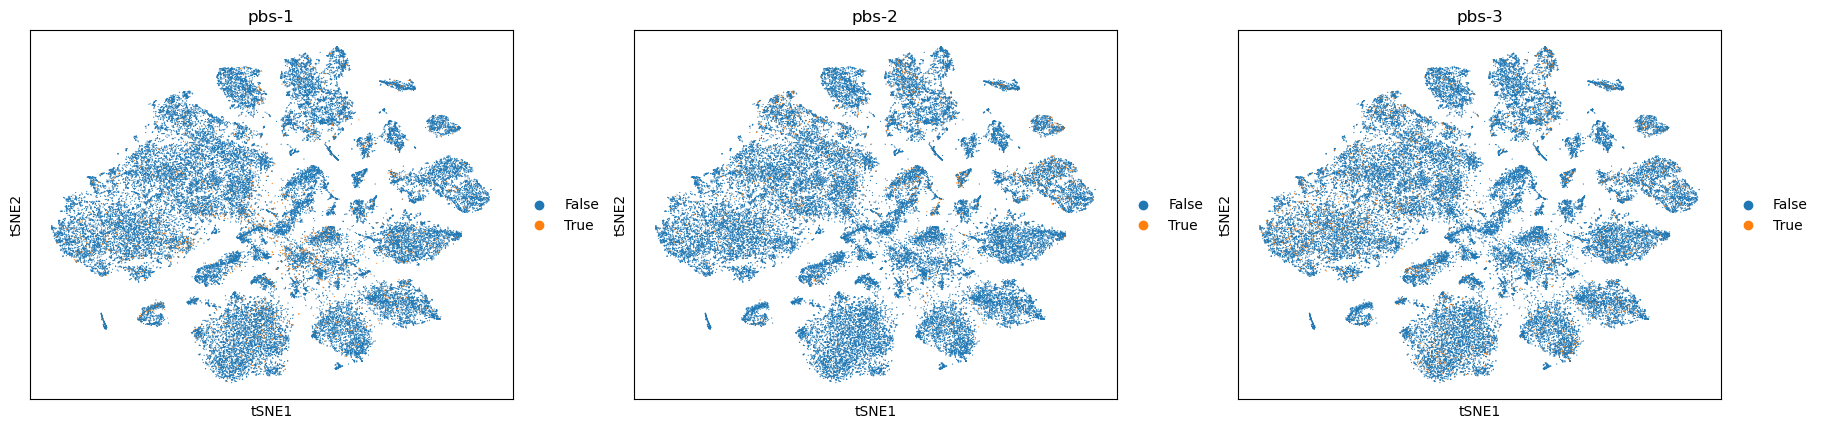

In [41]:
# sc.pp.highly_variable_genes(all_noise_er)
all_noise_er_hvg = all_noise_er[:, all_noise_er.var["highly_variable"]].copy()
gse.find_clusters(all_noise_er_hvg, cluster_kwargs={"resolution": 0.5})
gse.calculate_tsne(all_noise_er_hvg, tsne_kwargs={"n_jobs": 3})
gse.visualize_tsne(all_noise_er_hvg, color=["pbs-1", "pbs-2", "pbs-3"])

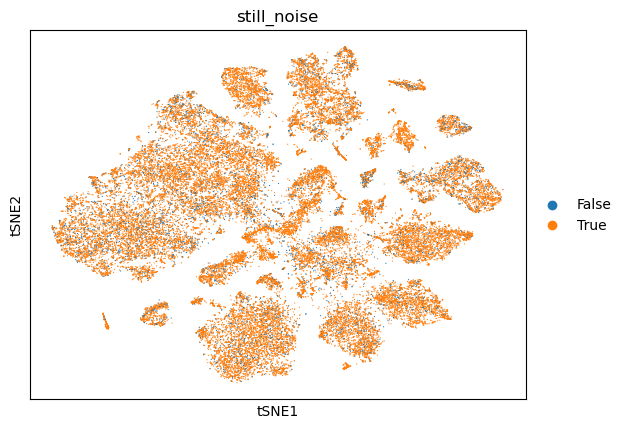

In [42]:
# all_noise_er_hvg = all_noise_er[:, all_noise_er.var["highly_variable"]].copy()
# gse.find_clusters(all_noise_er_hvg, cluster_kwargs={"resolution": 0.5})
# gse.calculate_tsne(all_noise_er_hvg, tsne_kwargs={"n_jobs": 3})
gse.visualize_tsne(all_noise_er_hvg, color=["still_noise"])

In [43]:
all_noise_copy = all_noise.copy()

In [44]:
all_noise_copy.n_obs, all_noise_er_hvg.n_obs

(87044, 42052)

In [45]:
gse.find_clusters(all_noise_copy, cluster_kwargs={"resolution": 0.5})

In [46]:
gse.calculate_tsne(all_noise_copy, tsne_kwargs={"n_jobs": 3})

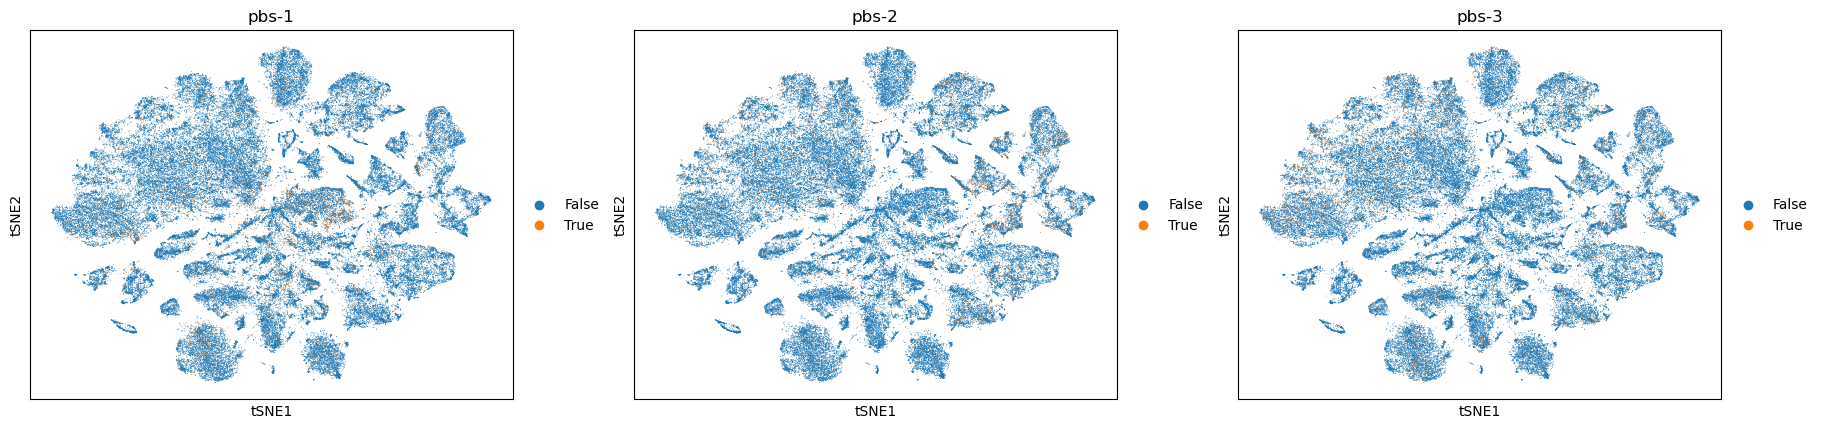

In [47]:
gse.visualize_tsne(all_noise_copy, color=["pbs-1", "pbs-2", "pbs-3"])

In [50]:
pbs_only = all_noise.copy()
conditions = [
    pbs_only.obs["pbs-1"] == 1,
    pbs_only.obs["pbs-2"] == 1,
    pbs_only.obs["pbs-3"] == 1,
]
choices = ["pbs-1", "pbs-2", "pbs-3"]
pbs_only.obs["pbs"] = np.select(conditions, choices, default="none")

In [57]:
pbs_only = pbs_only[pbs_only.obs["pbs"] != "none"].copy()

In [58]:
pbs_only

AnnData object with n_obs × n_vars = 11581 × 33538
    obs: 'adata-filename', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_low_num_genes', 'is_high_num_genes', 'is_high_mito', 'is_high_total_count', 'is_noise', 'zero_genes', 'zero_mito', 'zero_count', 'pbs-1', 'pbs-2', 'pbs-3', 'still_noise', 'cancer_type', 'pbs'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

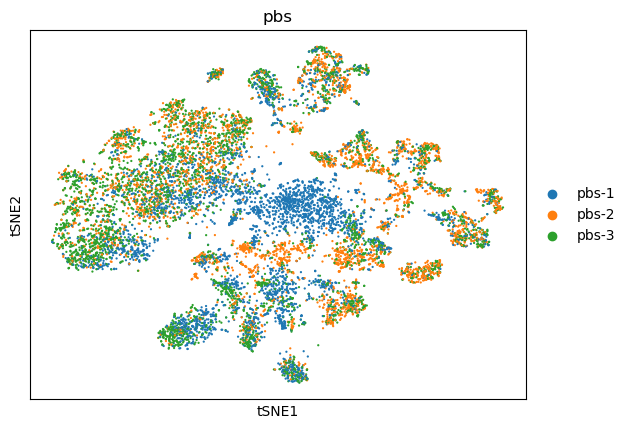

In [59]:
gse.find_clusters(pbs_only, cluster_kwargs={"resolution": 0.5})
gse.calculate_tsne(pbs_only, tsne_kwargs={"n_jobs": 3})
gse.visualize_tsne(pbs_only, color=["pbs"])

In [ ]:
gse.find_clusters(pbs_only, cluster_kwargs={"resolution": 0.015})
gse.calculate_tsne(pbs_only, tsne_kwargs={"n_jobs": 3})
gse.visualize_tsne(pbs_only, color=["pbs", "cancer_type"])

In [63]:
not_pbs_only = all_noise.copy()
conditions = [
    not_pbs_only.obs["pbs-1"] == 1,
    not_pbs_only.obs["pbs-2"] == 1,
    not_pbs_only.obs["pbs-3"] == 1,
]
choices = ["pbs-1", "pbs-2", "pbs-3"]
not_pbs_only.obs["pbs"] = np.select(conditions, choices, default="none")

In [64]:
not_pbs_only = pbs_only[pbs_only.obs["pbs"] != "none"].copy()
not_pbs_only

AnnData object with n_obs × n_vars = 11581 × 33538
    obs: 'adata-filename', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_low_num_genes', 'is_high_num_genes', 'is_high_mito', 'is_high_total_count', 'is_noise', 'zero_genes', 'zero_mito', 'zero_count', 'pbs-1', 'pbs-2', 'pbs-3', 'still_noise', 'cancer_type', 'pbs', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'pbs_colors'
    obsm: 'X_pca', 'X_tsne'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

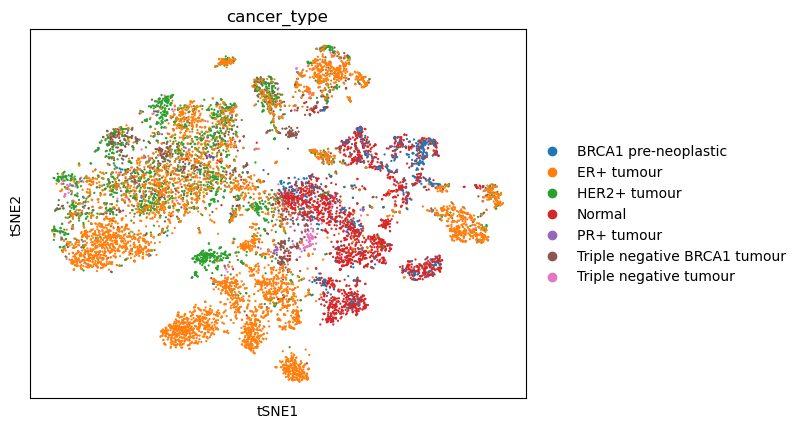

In [65]:
gse.find_clusters(not_pbs_only, cluster_kwargs={"resolution": 0.015})
gse.calculate_tsne(not_pbs_only, tsne_kwargs={"n_jobs": 3})
gse.visualize_tsne(not_pbs_only, color=["cancer_type"])